In [3]:
!pip install pandas --upgrade

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 45.2 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.3 which is incompatible.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Load data from pickle file with the upgraded version of pandas

In [1]:
import pickle
with open('/content/drive/MyDrive/spx-data/spx_0123dte_6mo.pkl', 'rb') as f:
    data = pickle.load(f)
print(type(data))          # e.g., <class 'pandas.core.frame.DataFrame'>
print(data.items())          # if it's a list/array, preview first rows

<class 'dict'>
dict_items([('meta', {'db_path': 'data/processed/spx_options.duckdb', 'start': '2025-12-03', 'end': '2026-06-01', 'freq': '1min (native)', 'tz': 'ts_utc is naive UTC; ts_et is naive ET (America/New_York)', 'dte_set': [0, 1, 2], 'row_counts': {'options': 7549134, 'spot': 47651}, 'columns': {'options': ['ts_utc', 'ts_et', 'underlying', 'expiry', 'dte', 'strike', 'right', 'open', 'high', 'low', 'close', 'volume'], 'spot': ['ts_utc', 'ts_et', 'close']}, 'notes': ['Options: 0/1/2 DTE only, 1-min native bars. OHLCV + minimal contract identifier.', 'underlying column kept because DTE 1/2 has BOTH SPX (AM-settled monthly) and SPXW (PM-settled). A (ts,expiry,strike,right) tuple alone is NOT unique on 3rd-Friday monthly expiry dates where both contracts trade.', 'DTE 0 rows are all SPXW (SPX is AM-settled and has no 0DTE intraday).', "Spot: SYNTHETIC:SPXW close only, 1-min. Synthetic spot is derived from options via put-call parity inside the ETL — it's not a market quote.", 'Gree

In [2]:
meta, spot, options = data["meta"], data["spot"], data["options"]

In [3]:
meta

{'db_path': 'data/processed/spx_options.duckdb',
 'start': '2025-12-03',
 'end': '2026-06-01',
 'freq': '1min (native)',
 'tz': 'ts_utc is naive UTC; ts_et is naive ET (America/New_York)',
 'dte_set': [0, 1, 2],
 'row_counts': {'options': 7549134, 'spot': 47651},
 'columns': {'options': ['ts_utc',
   'ts_et',
   'underlying',
   'expiry',
   'dte',
   'strike',
   'right',
   'open',
   'high',
   'low',
   'close',
   'volume'],
  'spot': ['ts_utc', 'ts_et', 'close']},
 'notes': ['Options: 0/1/2 DTE only, 1-min native bars. OHLCV + minimal contract identifier.',
  'underlying column kept because DTE 1/2 has BOTH SPX (AM-settled monthly) and SPXW (PM-settled). A (ts,expiry,strike,right) tuple alone is NOT unique on 3rd-Friday monthly expiry dates where both contracts trade.',
  'DTE 0 rows are all SPXW (SPX is AM-settled and has no 0DTE intraday).',
  "Spot: SYNTHETIC:SPXW close only, 1-min. Synthetic spot is derived from options via put-call parity inside the ETL — it's not a market q

In [4]:
spot.tail()

,ts_utc,ts_et,close
47646,2026-06-01 19:56:00,2026-06-01 15:56:00,7598.850
47647,2026-06-01 19:57:00,2026-06-01 15:57:00,7598.645
47648,2026-06-01 19:58:00,2026-06-01 15:58:00,7599.300
47649,2026-06-01 19:59:00,2026-06-01 15:59:00,7600.270
47650,2026-06-01 20:00:00,2026-06-01 16:00:00,7600.050


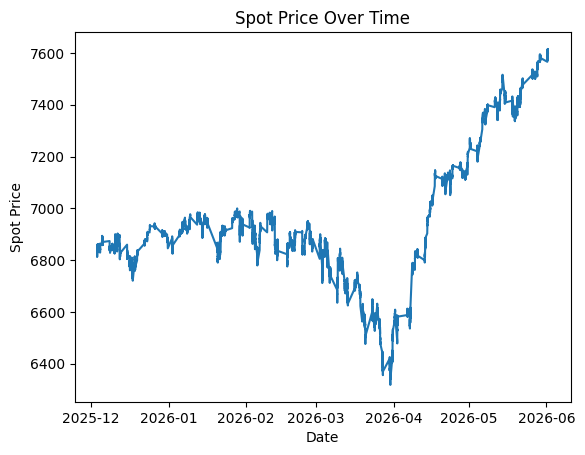

In [5]:
import matplotlib.pyplot as plt
plt.plot(spot['ts_et'], spot['close'])
plt.xlabel('Date')
plt.ylabel('Spot Price')
plt.title('Spot Price Over Time')
plt.show()

In [7]:
options.head()

,ts_utc,ts_et,underlying,expiry,dte,strike,right,open,high,low,close,volume
0,2025-12-03 14:30:00,2025-12-03 09:30:00,SPXW,2025-12-03,0,6250.0,P,0.03,0.03,0.03,0.03,30
1,2025-12-03 14:30:00,2025-12-03 09:30:00,SPXW,2025-12-03,0,6400.0,P,0.05,0.05,0.03,0.03,184
2,2025-12-03 14:30:00,2025-12-03 09:30:00,SPXW,2025-12-03,0,6440.0,P,0.05,0.05,0.05,0.05,4
3,2025-12-03 14:30:00,2025-12-03 09:30:00,SPXW,2025-12-03,0,6455.0,P,0.05,0.05,0.05,0.05,10
4,2025-12-03 14:30:00,2025-12-03 09:30:00,SPXW,2025-12-03,0,6460.0,P,0.05,0.05,0.05,0.05,10


##Choose trading day, expiry, snapshot time

We pick 2026-01-15 (Thursday), expiry 2026-01-16 (Friday, 1 DTE), snapshot 12:00:00 ET.
We use underlying SPXW (not SPX) – as working with 1 dte option data

In [36]:
import pandas as pd
day = "2026-01-15"
exp = "2026-01-16"
snap_time = "12:00:00"

# Convert ts_et to datetime (assuming naive US/Eastern)
options["ts_et"] = pd.to_datetime(options["ts_et"])
spot["ts_et"] = pd.to_datetime(spot["ts_et"])

# Keep only the chosen expiry and underlying (choose SPX for PM‑settled)
mask = (options["expiry"] == exp) & (options["underlying"] == "SPXW")
chain = options[mask].copy()

# Now pick the snapshot minute
snap = chain[chain["ts_et"].dt.strftime("%Y-%m-%d %H:%M:%S") == f"{day} {snap_time}"]

##Derive forward price using 10‑year Treasury yield

Synthetic spot (spot_snap) is provided from put‑call parity inside the pipeline.

Risk‑free rate r = 10‑year Treasury yield on 2026‑01‑15. We assume 4.5% (0.045).

Dividend yield q = 0 (for SPX options, dividends are negligible over 1 day).

Time to expiry T in years (calendar days / 365.25).

Forward price
F = S×exp(r−q)T=S×erT
F=S×exp(r−q)T
 =S×exp(rT).

In [37]:
import datetime as dt
import numpy as np

expiry_date = dt.datetime.strptime(exp, "%Y-%m-%d")
snap_date = dt.datetime.strptime(day, "%Y-%m-%d")
T = (expiry_date - snap_date).days / 365.25   # ~0.00274 for 1 DTE

spot_snap = spot[spot["ts_et"] == snap.iloc[0]["ts_et"]]["close"]
if len(spot_snap) == 0:
    spot_snap = spot.iloc[(spot["ts_et"] - snap.iloc[0]["ts_et"]).abs().argmin()]["close"]
else:
    spot_snap = spot_snap.iloc[0]


# 10‑year Treasury yield (example value, would be fetched from data source)
r = 0.045   # 4.5%
q = 0.0

# Forward price
F = spot_snap * np.exp((r - q) * T)

print(f"Synthetic spot = {spot_snap:.2f}")
print(f"Risk‑free rate (10y Treasury) = {r*100:.2f}%")
print(f"Time to expiry (years) = {T:.6f}")
print(f"Forward price = {F:.2f}")

Synthetic spot = 6974.69
Risk‑free rate (10y Treasury) = 4.50%
Time to expiry (years) = 0.002738
Forward price = 6975.55


## Compute implied volatilities (Black‑76)
Use only out‑of‑the‑money options:

Calls with strike > F

Puts with strike < F

The Black‑76 formula now uses the actual r (not zero) because the forward already incorporates carry.

In [38]:
from scipy.stats import norm
from scipy.optimize import brentq, least_squares
import numpy as np

def black_76(F, K, T, r, sigma, right):
    d1 = (np.log(F/K) + (sigma**2/2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    if right == 'C':
        price = np.exp(-r*T) * (F * norm.cdf(d1) - K * norm.cdf(d2))
    else:
        price = np.exp(-r*T) * (K * norm.cdf(-d2) - F * norm.cdf(-d1))
    return price

def implied_vol(price, F, K, T, r, right):
    if price <= 0:
        return np.nan
    func = lambda sigma: black_76(F, K, T, r, sigma, right) - price
    try:
        return brentq(func, 1e-6, 5.0)
    except:
        return np.nan

# Filter OTM options relative to forward
otm_mask = ((snap["right"] == "C") & (snap["strike"] > F)) | \
           ((snap["right"] == "P") & (snap["strike"] < F))
otm_snap = snap[otm_mask].copy()

otm_snap["iv"] = otm_snap.apply(
    lambda row: implied_vol(row["close"], F, row["strike"], T, r, row["right"]),
    axis=1
)
otm_snap = otm_snap.dropna(subset=["iv"])
print(f"Computed IVs for {len(otm_snap)} OTM options")

Computed IVs for 37 OTM options


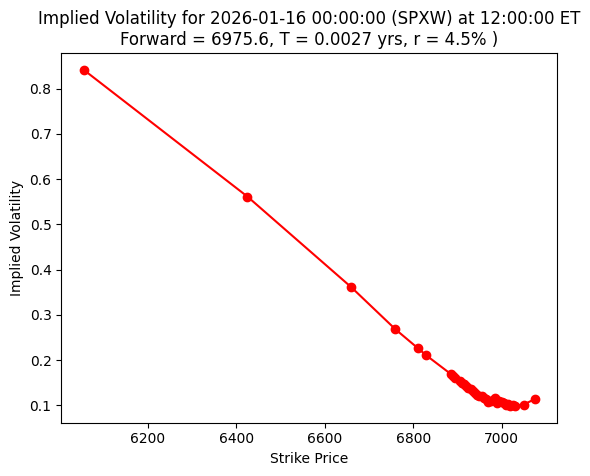

In [46]:
import matplotlib.pyplot as plt

plt.plot(otm_snap['strike'],otm_snap['iv'], label='IV vs Strike price', marker='o', color='red')
plt.xlabel('Strike Price')
plt.ylabel('Implied Volatility')
plt.title(f'Implied Volatility for {expiry_date} ({'SPXW'}) at {snap_time} ET\nForward = {F:.1f}, T = {T:.4f} yrs, r = {r*100:.1f}% )')
plt.show()

##Prepare data for SVI fit
Total implied variance w(k) = σ² * T vs log‑moneyness k = ln(K/F).


## SVI function and fitting

SVI: w(k) = a + b * ( ρ*(k - m) + sqrt((k - m)^2 + σ²) )
Bounds: b ≥ 0, |ρ| < 1, σ ≥ 0.

In [39]:
k = np.log(otm_snap["strike"] / F)
w = otm_snap["iv"]**2 * T
def svi(k, a, b, rho, m, sigma):
    return a + b * (rho * (k - m) + np.sqrt((k - m)**2 + sigma**2))

def residuals(params, k, w):
    a, b, rho, m, sigma = params
    return w - svi(k, a, b, rho, m, sigma)

x0 = [0.04, 0.2, -0.3, 0.0, 0.1]
bounds = ([-np.inf, 0.0, -0.999, -np.inf, 0.0],
          [ np.inf, 1.0,  0.999,  np.inf, 1.0])

res = least_squares(residuals, x0, bounds=bounds, args=(k, w))
a_fit, b_fit, rho_fit, m_fit, sigma_fit = res.x

print("SVI parameters:")
print(f"a  = {a_fit:.6f}")
print(f"b  = {b_fit:.6f}")
print(f"ρ  = {rho_fit:.6f}")
print(f"m  = {m_fit:.6f}")
print(f"σ  = {sigma_fit:.6f}")

SVI parameters:
a  = -0.001431
b  = 0.018732
ρ  = -0.175986
m  = -0.006947
σ  = 0.079119


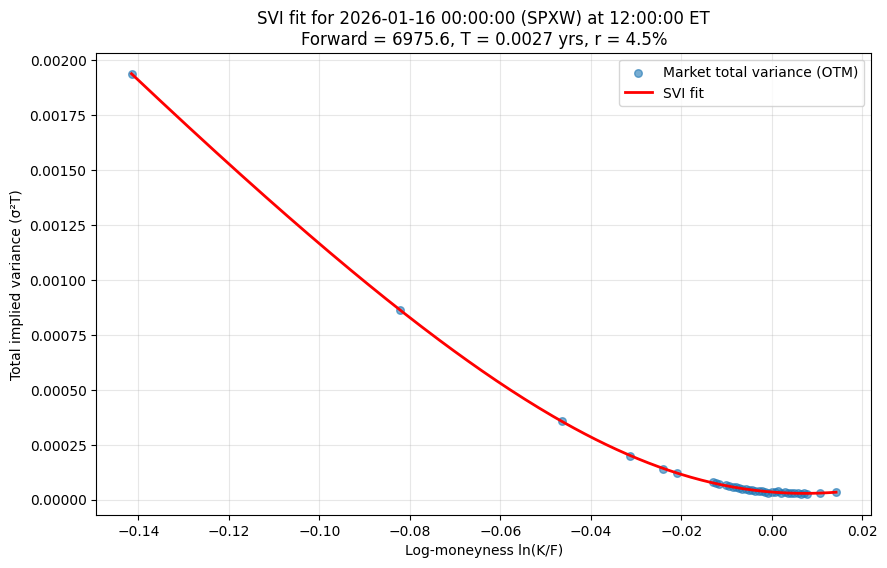

In [41]:
k_grid = np.linspace(k.min(), k.max(), 200)
w_fit = svi(k_grid, a_fit, b_fit, rho_fit, m_fit, sigma_fit)

plt.figure(figsize=(10,6))
plt.scatter(k, w, label='Market total variance (OTM)', alpha=0.6, s=30)
plt.plot(k_grid, w_fit, 'r-', label='SVI fit', linewidth=2)
plt.xlabel('Log-moneyness ln(K/F)')
plt.ylabel('Total implied variance (σ²T)')
plt.title(f'SVI fit for {expiry_date} ({'SPXW'}) at {snap_time} ET\nForward = {F:.1f}, T = {T:.4f} yrs, r = {r*100:.1f}%')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [48]:
import numpy as np

# Calculate SVI-fitted total variance for the market k values
w_fit_market_k = svi(k, a_fit, b_fit, rho_fit, m_fit, sigma_fit)

# Convert SVI-fitted total variance to implied volatility for market k values
iv_fit_market_k = np.sqrt(w_fit_market_k / T)

# Calculate RMSE
rmse = np.sqrt(np.mean((otm_snap['iv'] - iv_fit_market_k)**2))

print(f"RMSE between market IV and SVI-fitted IV: {rmse:.6f}")

RMSE between market IV and SVI-fitted IV: 0.002560


## Stretch: Butterfly (static) arbitrage check

We check whether the fitted SVI smile violates the no‑arbitrage condition that the risk‑neutral probability density (derived from call prices) is non‑negative. This is equivalent to the call price being convex in strike.

### Method

1. From the SVI total variance `w(k)`, compute call prices (Black‑76) for a dense grid of log‑moneyness.
2. Compute the second derivative of call price with respect to strike using finite differences.
3. If the second derivative is negative at any strike, a butterfly arbitrage exists.


We use the **SVI parameters** obtained from the fit. The grid should cover the range of strikes where we have market data plus a small extrapolation.

Butterfly arbitrage exists: False


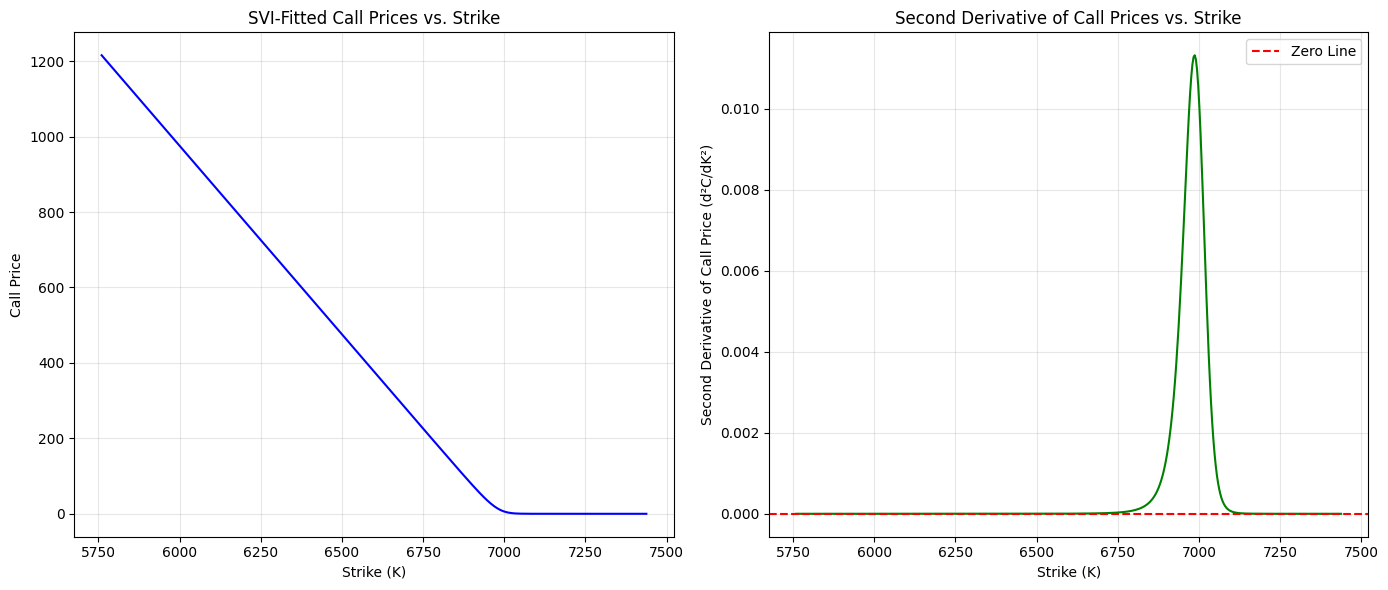

In [50]:
import matplotlib.pyplot as plt

# 1. Define a dense grid of log-moneyness (k_arb), wider than observed k
k_min_arb = k.min() - 0.05
k_max_arb = k.max() + 0.05
k_arb = np.linspace(k_min_arb, k_max_arb, 500)

# 2. Convert k_arb to strikes (K_arb)
K_arb = F * np.exp(k_arb)

# 3. Calculate SVI total variance (w_arb) for k_arb
w_arb = svi(k_arb, a_fit, b_fit, rho_fit, m_fit, sigma_fit)

# Ensure w_arb is non-negative for valid IVs (SVI can sometimes produce negative w for extreme k)
w_arb[w_arb < 0] = 1e-10 # Set a small positive value if negative

# 4. Convert total variance to implied volatility (iv_arb)
iv_arb = np.sqrt(w_arb / T)

# 5. Calculate call prices (call_prices_arb) for K_arb
call_prices_arb = np.array([black_76(F, K_val, T, r, iv_val, 'C') for K_val, iv_val in zip(K_arb, iv_arb)])

# 6. Compute the first and second derivatives of call prices with respect to strike
# Using np.gradient for numerical derivatives
dC_dK = np.gradient(call_prices_arb, K_arb)
d2C_dK2 = np.gradient(dC_dK, K_arb)

# 7. Check for negative second derivatives (butterfly arbitrage condition)
butterfly_arbitrage_exists = np.any(d2C_dK2 < -1e-6) # Use a small tolerance for floating point issues

print(f"Butterfly arbitrage exists: {butterfly_arbitrage_exists}")

# 8. Visualize the call prices and their second derivatives
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(K_arb, call_prices_arb, 'b-')
plt.xlabel('Strike (K)')
plt.ylabel('Call Price')
plt.title('SVI-Fitted Call Prices vs. Strike')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(K_arb, d2C_dK2, 'g-')
plt.axhline(0, color='red', linestyle='--', label='Zero Line')
plt.xlabel('Strike (K)')
plt.ylabel('Second Derivative of Call Price (d²C/dK²)')
plt.title('Second Derivative of Call Prices vs. Strike')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()